In [ ]:
# kmap.py

AB = ['00', '01', '11', '10']
C  = ['0', '1']

F = [
    [1, 1],   # AB=00
    [1, 1],   # AB=01
    [0, 0],   # AB=11
    [0, 0],   # AB=10
]

# find the 1s
ones = []
for i, ab in enumerate(AB):
    for j, c in enumerate(C):
        if F[i][j] == 1:
            ones.append(ab + c)

# find the expression
expression = []
for var_idx, var_name in enumerate(['A', 'B', 'C']):
    bits = [cell[var_idx] for cell in ones]
    if all(b == '1' for b in bits):
        expression.append(var_name)
    elif all(b == '0' for b in bits):
        expression.append(var_name + "'")

print("F =", " ".join(expression))




In [ ]:
# verify against F
print("\nVerification:")
for i, ab in enumerate(AB):
    for j, c in enumerate(C):
        A  = int(ab[0])
        B  = int(ab[1])
        Cv = int(c)

        predicted = int(A == 0)   # F = A'

        match = "✓" if predicted == F[i][j] else "✗"
        print(f"  A={A} B={B} C={Cv}  F={F[i][j]}  predicted={predicted}  {match}")

### black and white


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 4x4 black and white image (0=black, 1=white)
image = np.array([
    [0, 0, 1, 1],
    [0, 0, 1, 1],
    [1, 1, 0, 0],
    [1, 1, 0, 0]
])

plt.imshow(image, cmap='gray')
plt.title("Black and White Image")
plt.show()

In [ ]:
# treat each pixel and its right neighbour as inputs A, B
# output F is the pixel itself

A = []
B = []
F = []

for row in range(4):
    for col in range(3):   # stop at 3 so we always have a right neighbour
        A.append(image[row, col])
        B.append(image[row, col + 1])
        F.append(image[row, col + 1])

print("A:", A)
print("B:", B)
print("F:", F)

In [ ]:
# build truth table
print("\nA | B | F")
print("-" * 10)
for i in range(len(A)):
    print(f"{int(A[i])} | {int(B[i])} | {int(F[i])}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 10x10 checkerboard
image = np.zeros((10, 10), dtype=int)
for row in range(10):
    for col in range(10):
        if (row + col) % 2 == 0:
            image[row, col] = 1

# apply diagonal rule - F=1 if any diagonal is white
new_image = np.zeros((10, 10))

for row in range(1, 9):
    for col in range(1, 9):
        A = image[row-1, col-1]  # top-left
        B = image[row-1, col+1]  # top-right
        C = image[row+1, col-1]  # bottom-left
        D = image[row+1, col+1]  # bottom-right

        F = int(A == 1 or B == 1 or C == 1 or D == 1)
        new_image[row, col] = F

fig, axes = plt.subplots(1, 2)
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(new_image, cmap='gray')
axes[1].set_title("After Rule")
plt.show()

#### gauss field

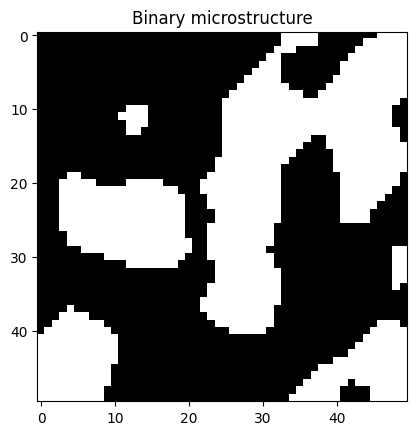

In [5]:

from pgs_tools import make_gaussian_fields, make_lithotype_map

# generate a microstructure
field_1, field_2 = make_gaussian_fields(grid_size=50, seed_1=0, seed_2=1, len_scale_1=5, len_scale_2=10)
litho = make_lithotype_map(field_1, field_2, Mat1=0.60, Mat2=0.40, Mat3=0.0)

# convert to binary: material 0 vs everything else
binary = (litho > 0).astype(int)


import matplotlib.pyplot as plt
plt.imshow(binary, cmap='gray')
plt.title("Binary microstructure")
plt.show()

In [6]:
A_list = []
B_list = []
C_list = []
D_list = []
F_list = []

rows, cols = binary.shape

for row in range(1, rows - 1):
    for col in range(1, cols - 1):
        A = binary[row-1, col-1]  # top-left
        B = binary[row-1, col+1]  # top-right
        C = binary[row+1, col-1]  # bottom-left
        D = binary[row+1, col+1]  # bottom-right
        F = binary[row, col]      # centre pixel

        A_list.append(int(A))
        B_list.append(int(B))
        C_list.append(int(C))
        D_list.append(int(D))
        F_list.append(int(F))

print(f"Total samples: {len(F_list)}")
print(f"F=1 count: {sum(F_list)}")
print(f"F=0 count: {F_list.count(0)}")

print( sum(F_list)/len(F_list))  # proportion of F=1
print( F_list.count(0) / len(F_list))  # proportion of F=0

Total samples: 2304
F=1 count: 936
F=0 count: 1368
0.40625
0.59375


In [7]:
# find unique input combinations and their F values
from collections import defaultdict

counts = defaultdict(lambda: [0, 0])  # counts[ABCD] = [count_0, count_1]

for i in range(len(F_list)):
    key = (A_list[i], B_list[i], C_list[i], D_list[i])
    counts[key][F_list[i]] += 1

print("A B C D | F=0  F=1  | majority F")
print("-" * 40)
for key in sorted(counts.keys()):
    c0, c1 = counts[key]
    majority = 1 if c1 > c0 else 0
    print(f"{key} | {c0:4d}  {c1:4d} | {majority}")

A B C D | F=0  F=1  | majority F
----------------------------------------
(0, 0, 0, 0) | 1049     0 | 0
(0, 0, 0, 1) |   82     1 | 0
(0, 0, 1, 0) |   33     1 | 0
(0, 0, 1, 1) |   18    24 | 1
(0, 1, 0, 0) |   40     5 | 0
(0, 1, 0, 1) |   39    41 | 1
(0, 1, 1, 0) |    0     3 | 1
(0, 1, 1, 1) |    0    68 | 1
(1, 0, 0, 0) |   47     2 | 0
(1, 0, 1, 0) |   36    37 | 1
(1, 0, 1, 1) |    0    30 | 1
(1, 1, 0, 0) |   21    23 | 1
(1, 1, 0, 1) |    2    31 | 1
(1, 1, 1, 0) |    1    45 | 1
(1, 1, 1, 1) |    0   625 | 1


we are only looking at diags for now to keep it abcd if we add all neighbours wed have abcdefgh and that is a big map, could be worth finding out which neighbours matter most not sure how to do that yet but could be worth it